In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

worklist = pd.read_csv(
    "../data/predictions/ranked_maintenance_worklist.csv"
)

impact = pd.read_csv(
    "../data/predictions/operational_impact_predictions.csv"
)

print("Worklist shape:", worklist.shape)
print("Impact shape:", impact.shape)

display(worklist.head())
display(impact.head())

Worklist shape: (6, 17)
Impact shape: (2, 16)


,priority_rank,task_id,asset_id,section_id,department,maintenance_type,defect_type,severity,criticality,overdue_days,estimated_duration,required_manpower,status,failure_probability,urgency_score,priority_score,priority_category
0,1,TMS001,TRK001,NDL-MTJ-01,ENGINEERING,REPAIR,RAIL_CRACK,9,10,1,90,8,PENDING,0.0,0.718333,0.418833,MEDIUM
1,2,SMMS001,SIG001,MTJ-AGC-01,S&T,REPAIR,SIGNAL_DEGRADATION,8,9,0,45,3,PENDING,0.0,0.635000,0.370500,MEDIUM
2,3,TDMS001,OHE001,GWL-JHS-01,TRACTION,REPAIR,OHE_INSULATOR,7,9,0,60,5,PENDING,0.0,0.595000,0.358500,MEDIUM
3,4,TMS002,TRK002,NDL-MTJ-02,ENGINEERING,INSPECTION,TRACK_WEAR,4,8,0,60,5,PENDING,0.0,0.440000,0.292000,MEDIUM
4,5,TDMS002,OHE002,JHS-BINA-01,TRACTION,INSPECTION,OHE_CHECK,3,8,0,45,4,PENDING,0.0,0.400000,0.280000,MEDIUM


,task_id,asset_id,section_id,department,maintenance_type,estimated_duration,avg_predicted_trains,avg_passenger_trains,avg_freight_trains,traffic_intensity,affected_trains_estimate,synthetic_delay_minutes,operational_impact_score,operational_impact_category,predicted_delay_minutes,delay_prediction_error
0,SMMS002,SIG002,AGC-GWL-01,S&T,INSPECTION,30,243.576523,142.366255,101.674897,0.842983,5.074511,105.06,0.611711,HIGH,160.288458,55.228458
1,TDMS002,OHE002,JHS-BINA-01,TRACTION,INSPECTION,45,183.568691,107.152263,76.609053,0.635305,5.736522,117.62,0.572357,HIGH,160.288458,42.668458


In [2]:
print("Worklist columns:")
print(worklist.columns.tolist())

print("\nImpact columns:")
print(impact.columns.tolist())

Worklist columns:
['priority_rank', 'task_id', 'asset_id', 'section_id', 'department', 'maintenance_type', 'defect_type', 'severity', 'criticality', 'overdue_days', 'estimated_duration', 'required_manpower', 'status', 'failure_probability', 'urgency_score', 'priority_score', 'priority_category']

Impact columns:
['task_id', 'asset_id', 'section_id', 'department', 'maintenance_type', 'estimated_duration', 'avg_predicted_trains', 'avg_passenger_trains', 'avg_freight_trains', 'traffic_intensity', 'affected_trains_estimate', 'synthetic_delay_minutes', 'operational_impact_score', 'operational_impact_category', 'predicted_delay_minutes', 'delay_prediction_error']


In [3]:
decision_data = worklist.merge(
    impact[
        [
            "task_id",
            "predicted_delay_minutes",
            "operational_impact_score",
            "operational_impact_category",
            "traffic_intensity",
            "affected_trains_estimate"
        ]
    ],
    on="task_id",
    how="left"
)

print(
    "Decision dataset shape:",
    decision_data.shape
)

display(decision_data.head(20))

Decision dataset shape: (6, 22)


,priority_rank,task_id,asset_id,section_id,department,maintenance_type,defect_type,severity,criticality,overdue_days,...,status,failure_probability,urgency_score,priority_score,priority_category,predicted_delay_minutes,operational_impact_score,operational_impact_category,traffic_intensity,affected_trains_estimate
0,1,TMS001,TRK001,NDL-MTJ-01,ENGINEERING,REPAIR,RAIL_CRACK,9,10,1,...,PENDING,0.0,0.718333,0.418833,MEDIUM,NaN,NaN,NaN,NaN,NaN
1,2,SMMS001,SIG001,MTJ-AGC-01,S&T,REPAIR,SIGNAL_DEGRADATION,8,9,0,...,PENDING,0.0,0.635000,0.370500,MEDIUM,NaN,NaN,NaN,NaN,NaN
2,3,TDMS001,OHE001,GWL-JHS-01,TRACTION,REPAIR,OHE_INSULATOR,7,9,0,...,PENDING,0.0,0.595000,0.358500,MEDIUM,NaN,NaN,NaN,NaN,NaN
3,4,TMS002,TRK002,NDL-MTJ-02,ENGINEERING,INSPECTION,TRACK_WEAR,4,8,0,...,PENDING,0.0,0.440000,0.292000,MEDIUM,NaN,NaN,NaN,NaN,NaN
4,5,TDMS002,OHE002,JHS-BINA-01,TRACTION,INSPECTION,OHE_CHECK,3,8,0,...,PENDING,0.0,0.400000,0.280000,MEDIUM,160.288458,0.572357,HIGH,0.635305,5.736522
5,6,SMMS002,SIG002,AGC-GWL-01,S&T,INSPECTION,SIGNAL_CHECK,3,7,0,...,PENDING,0.0,0.365000,0.249500,LOW,160.288458,0.611711,HIGH,0.842983,5.074511


In [4]:
decision_data["predicted_delay_minutes"] = (
    pd.to_numeric(
        decision_data["predicted_delay_minutes"],
        errors="coerce"
    )
    .fillna(0)
)

decision_data["operational_impact_score"] = (
    pd.to_numeric(
        decision_data["operational_impact_score"],
        errors="coerce"
    )
    .fillna(0)
)

decision_data["traffic_intensity"] = (
    pd.to_numeric(
        decision_data["traffic_intensity"],
        errors="coerce"
    )
    .fillna(0)
)

decision_data["affected_trains_estimate"] = (
    pd.to_numeric(
        decision_data["affected_trains_estimate"],
        errors="coerce"
    )
    .fillna(0)
)

print("Operational values cleaned.")

Operational values cleaned.


In [5]:
decision_data["failure_risk_factor"] = (
    pd.to_numeric(
        decision_data["failure_probability"],
        errors="coerce"
    )
    .fillna(0)
    .clip(0, 1)
)

In [6]:
decision_data["urgency_factor"] = (
    pd.to_numeric(
        decision_data["urgency_score"],
        errors="coerce"
    )
    .fillna(0)
    .clip(0, 1)
)

In [7]:
decision_data["criticality_factor"] = (
    pd.to_numeric(
        decision_data["criticality"],
        errors="coerce"
    )
    .fillna(0)
    / 10
).clip(0, 1)

In [8]:
decision_data["overdue_factor"] = (
    pd.to_numeric(
        decision_data["overdue_days"],
        errors="coerce"
    )
    .fillna(0)
    / 30
).clip(0, 1)

In [9]:
decision_data["duration_factor"] = (
    pd.to_numeric(
        decision_data["estimated_duration"],
        errors="coerce"
    )
    .fillna(0)
    / 180
).clip(0, 1)

In [10]:
decision_data["traffic_factor"] = (
    decision_data["traffic_intensity"]
    .clip(0, 1)
)

In [11]:
decision_data["operational_factor"] = (
    decision_data["operational_impact_score"]
    .clip(0, 1)
)

In [12]:
decision_data["maintenance_decision_score"] = (
    0.25 * decision_data["failure_risk_factor"]
    + 0.20 * decision_data["urgency_factor"]
    + 0.15 * decision_data["criticality_factor"]
    + 0.10 * decision_data["overdue_factor"]
    + 0.05 * decision_data["duration_factor"]
    + 0.10 * decision_data["traffic_factor"]
    + 0.15 * decision_data["operational_factor"]
)

In [13]:
decision_data["decision_category"] = pd.cut(
    decision_data["maintenance_decision_score"],
    bins=[
        -np.inf,
        0.25,
        0.50,
        0.75,
        np.inf
    ],
    labels=[
        "LOW",
        "MEDIUM",
        "HIGH",
        "CRITICAL"
    ]
)

display(
    decision_data[
        [
            "task_id",
            "section_id",
            "department",
            "maintenance_decision_score",
            "decision_category"
        ]
    ].sort_values(
        "maintenance_decision_score",
        ascending=False
    ).head(20)
)

,task_id,section_id,department,maintenance_decision_score,decision_category
5,SMMS002,AGC-GWL-01,S&T,0.362388,MEDIUM
4,TDMS002,JHS-BINA-01,TRACTION,0.361884,MEDIUM
0,TMS001,NDL-MTJ-01,ENGINEERING,0.322000,MEDIUM
1,SMMS001,MTJ-AGC-01,S&T,0.274500,MEDIUM
2,TDMS001,GWL-JHS-01,TRACTION,0.270667,MEDIUM
3,TMS002,NDL-MTJ-02,ENGINEERING,0.224667,LOW


In [14]:
decision_data = decision_data.sort_values(
    [
        "maintenance_decision_score",
        "failure_risk_factor",
        "criticality_factor"
    ],
    ascending=[False, False, False]
).reset_index(drop=True)

decision_data.insert(
    0,
    "decision_rank",
    np.arange(1, len(decision_data) + 1)
)

display(
    decision_data.head(20)
)

,decision_rank,priority_rank,task_id,asset_id,section_id,department,maintenance_type,defect_type,severity,criticality,...,affected_trains_estimate,failure_risk_factor,urgency_factor,criticality_factor,overdue_factor,duration_factor,traffic_factor,operational_factor,maintenance_decision_score,decision_category
0,1,6,SMMS002,SIG002,AGC-GWL-01,S&T,INSPECTION,SIGNAL_CHECK,3,7,...,5.074511,0.0,0.365000,0.7,0.000000,0.166667,0.842983,0.611711,0.362388,MEDIUM
1,2,5,TDMS002,OHE002,JHS-BINA-01,TRACTION,INSPECTION,OHE_CHECK,3,8,...,5.736522,0.0,0.400000,0.8,0.000000,0.250000,0.635305,0.572357,0.361884,MEDIUM
2,3,1,TMS001,TRK001,NDL-MTJ-01,ENGINEERING,REPAIR,RAIL_CRACK,9,10,...,0.000000,0.0,0.718333,1.0,0.033333,0.500000,0.000000,0.000000,0.322000,MEDIUM
3,4,2,SMMS001,SIG001,MTJ-AGC-01,S&T,REPAIR,SIGNAL_DEGRADATION,8,9,...,0.000000,0.0,0.635000,0.9,0.000000,0.250000,0.000000,0.000000,0.274500,MEDIUM
4,5,3,TDMS001,OHE001,GWL-JHS-01,TRACTION,REPAIR,OHE_INSULATOR,7,9,...,0.000000,0.0,0.595000,0.9,0.000000,0.333333,0.000000,0.000000,0.270667,MEDIUM
5,6,4,TMS002,TRK002,NDL-MTJ-02,ENGINEERING,INSPECTION,TRACK_WEAR,4,8,...,0.000000,0.0,0.440000,0.8,0.000000,0.333333,0.000000,0.000000,0.224667,LOW


In [15]:
print(
    decision_data[
        "maintenance_decision_score"
    ].describe()
)

count    6.000000
mean     0.302684
std      0.055405
min      0.224667
25%      0.271625
50%      0.298250
75%      0.351913
max      0.362388
Name: maintenance_decision_score, dtype: float64


In [16]:
category_distribution = (
    decision_data["decision_category"]
    .value_counts()
    .reindex(
        ["CRITICAL", "HIGH", "MEDIUM", "LOW"],
        fill_value=0
    )
)

print("Decision Category Distribution")
print(category_distribution)

Decision Category Distribution
decision_category
CRITICAL    0
HIGH        0
MEDIUM      5
LOW         1
Name: count, dtype: int64


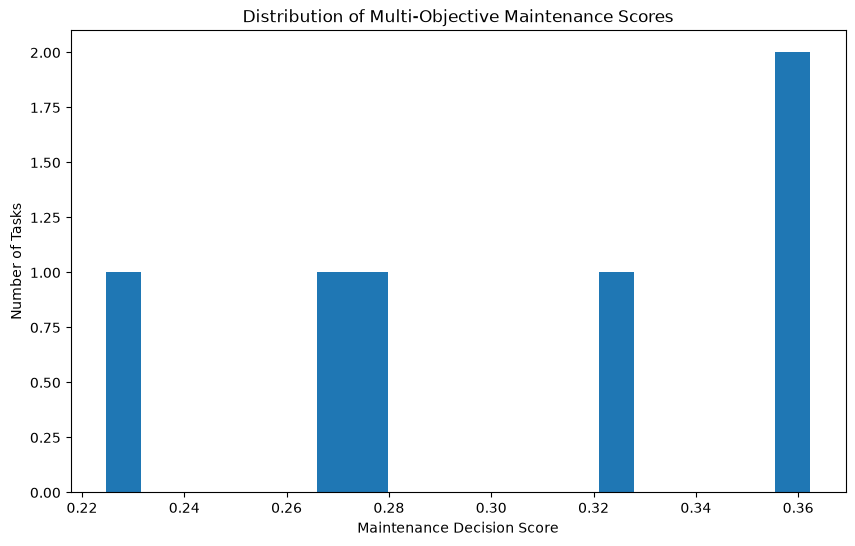

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(
    decision_data["maintenance_decision_score"],
    bins=20
)

plt.xlabel("Maintenance Decision Score")
plt.ylabel("Number of Tasks")
plt.title(
    "Distribution of Multi-Objective Maintenance Scores"
)

plt.show()

In [18]:
score_breakdown = decision_data[
    [
        "task_id",
        "section_id",
        "department",
        "failure_risk_factor",
        "urgency_factor",
        "criticality_factor",
        "overdue_factor",
        "duration_factor",
        "traffic_factor",
        "operational_factor",
        "maintenance_decision_score",
        "decision_category"
    ]
].copy()

display(
    score_breakdown.head(20)
)

,task_id,section_id,department,failure_risk_factor,urgency_factor,criticality_factor,overdue_factor,duration_factor,traffic_factor,operational_factor,maintenance_decision_score,decision_category
0,SMMS002,AGC-GWL-01,S&T,0.0,0.365000,0.7,0.000000,0.166667,0.842983,0.611711,0.362388,MEDIUM
1,TDMS002,JHS-BINA-01,TRACTION,0.0,0.400000,0.8,0.000000,0.250000,0.635305,0.572357,0.361884,MEDIUM
2,TMS001,NDL-MTJ-01,ENGINEERING,0.0,0.718333,1.0,0.033333,0.500000,0.000000,0.000000,0.322000,MEDIUM
3,SMMS001,MTJ-AGC-01,S&T,0.0,0.635000,0.9,0.000000,0.250000,0.000000,0.000000,0.274500,MEDIUM
4,TDMS001,GWL-JHS-01,TRACTION,0.0,0.595000,0.9,0.000000,0.333333,0.000000,0.000000,0.270667,MEDIUM
5,TMS002,NDL-MTJ-02,ENGINEERING,0.0,0.440000,0.8,0.000000,0.333333,0.000000,0.000000,0.224667,LOW


In [19]:
department_scores = (
    decision_data
    .groupby("department", observed=True)
    .agg(
        task_count=("task_id", "count"),
        average_score=(
            "maintenance_decision_score",
            "mean"
        ),
        maximum_score=(
            "maintenance_decision_score",
            "max"
        ),
        critical_tasks=(
            "decision_category",
            lambda x: (x == "CRITICAL").sum()
        )
    )
    .sort_values(
        "average_score",
        ascending=False
    )
)

display(department_scores)

,task_count,average_score,maximum_score,critical_tasks
department,,,,
S&T,2,0.318444,0.362388,0
TRACTION,2,0.316275,0.361884,0
ENGINEERING,2,0.273333,0.322000,0


In [20]:
section_scores = (
    decision_data
    .groupby("section_id", observed=True)
    .agg(
        task_count=("task_id", "count"),
        average_score=(
            "maintenance_decision_score",
            "mean"
        ),
        maximum_score=(
            "maintenance_decision_score",
            "max"
        ),
        critical_tasks=(
            "decision_category",
            lambda x: (x == "CRITICAL").sum()
        )
    )
    .sort_values(
        "average_score",
        ascending=False
    )
)

display(section_scores)

,task_count,average_score,maximum_score,critical_tasks
section_id,,,,
AGC-GWL-01,1,0.362388,0.362388,0
JHS-BINA-01,1,0.361884,0.361884,0
NDL-MTJ-01,1,0.322000,0.322000,0
MTJ-AGC-01,1,0.274500,0.274500,0
GWL-JHS-01,1,0.270667,0.270667,0
NDL-MTJ-02,1,0.224667,0.224667,0


In [21]:
decision_data.to_csv(
    "../data/predictions/multi_objective_decision_scores.csv",
    index=False
)

print(
    "Saved:",
    "../data/predictions/multi_objective_decision_scores.csv"
)

Saved: ../data/predictions/multi_objective_decision_scores.csv
